In [ ]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trade_files = sorted(glob.glob("../../../data_capsule/ROUND_3/trades_round_3_day_*.csv"))
trades = pd.concat([pd.read_csv(f, sep=';') for f in trade_files], ignore_index=True)

# =========================
# LOAD DATA
# =========================
price_files = sorted(glob.glob("../../../data_capsule/ROUND_3/prices_round_3_day_*.csv"))
prices = pd.concat([pd.read_csv(f, sep=';') for f in price_files], ignore_index=True)

# Clean
trades = trades.rename(columns={"symbol": "product"})
trades = trades.sort_values("timestamp")

# Extract strike for vouchers
trades["strike"] = trades["product"].str.extract(r'VEV_(\d+)')
trades["strike"] = trades["strike"].astype(float)

trades.head()

,timestamp,buyer,seller,product,currency,price,quantity,strike
2715,900,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5262.0,8,NaN
2716,1300,NaN,NaN,VEV_4000,XIRECS,1251.0,3,4000.0
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,NaN
2717,2700,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5269.0,8,NaN
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,6000.0


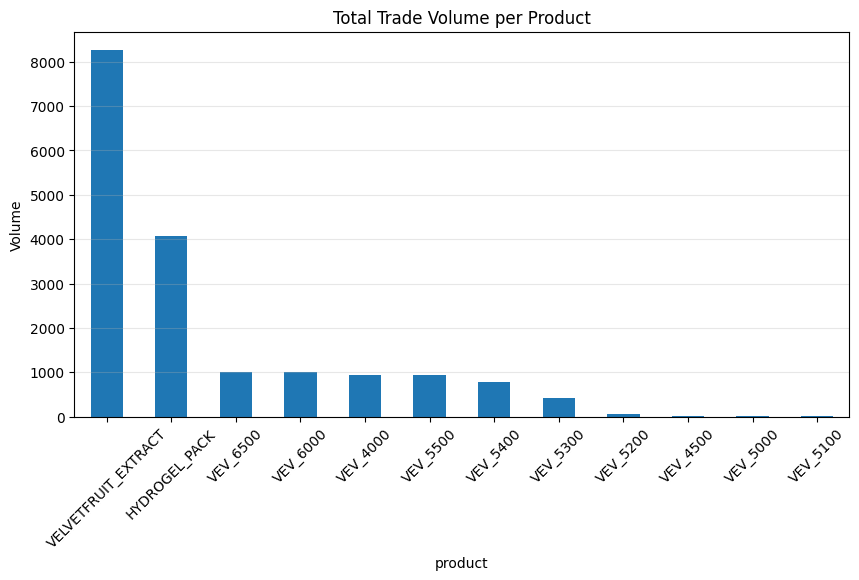

In [ ]:
vol = trades.groupby(["product", "timestamp"])["quantity"].sum().reset_index()

# If you have day column in trades, use it directly
# otherwise approximate day by timestamp buckets if needed

vol_product = trades.groupby("product")["quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
vol_product.plot(kind="bar")

plt.title("Total Trade Volume per Product")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

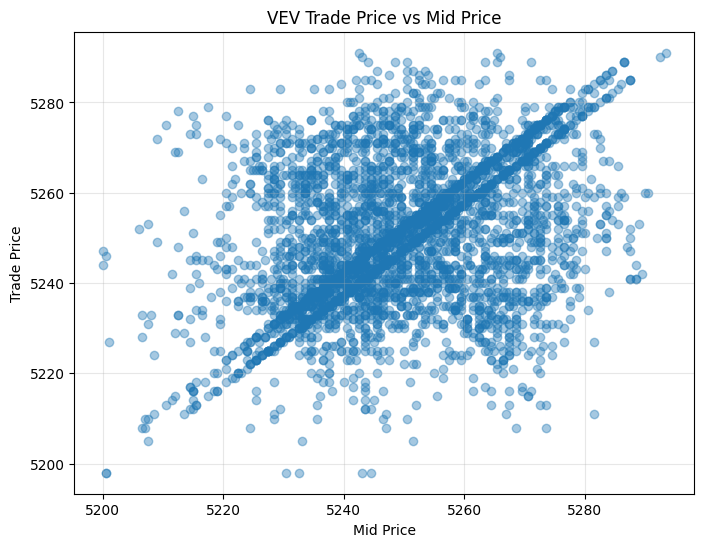

In [ ]:
vev_prices = prices[prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
vev_prices["mid"] = (vev_prices["bid_price_1"] + vev_prices["ask_price_1"]) / 2

vev_trades = trades[trades["product"] == "VELVETFRUIT_EXTRACT"]

merged = vev_trades.merge(
    vev_prices[["timestamp","mid"]],
    on="timestamp",
    how="left"
)


plt.figure(figsize=(8,6))
plt.scatter(merged["mid"], merged["price"], alpha=0.4)

plt.xlabel("Mid Price")
plt.ylabel("Trade Price")
plt.title("VEV Trade Price vs Mid Price")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
merged["direction"] = np.where(
    merged["price"] > merged["mid"], "BUY (lifting ask)",
    np.where(merged["price"] < merged["mid"], "SELL (hitting bid)", "MID")
)

print(merged["direction"].value_counts())

direction
BUY (lifting ask)     2200
SELL (hitting bid)    1904
MID                     12
Name: count, dtype: int64


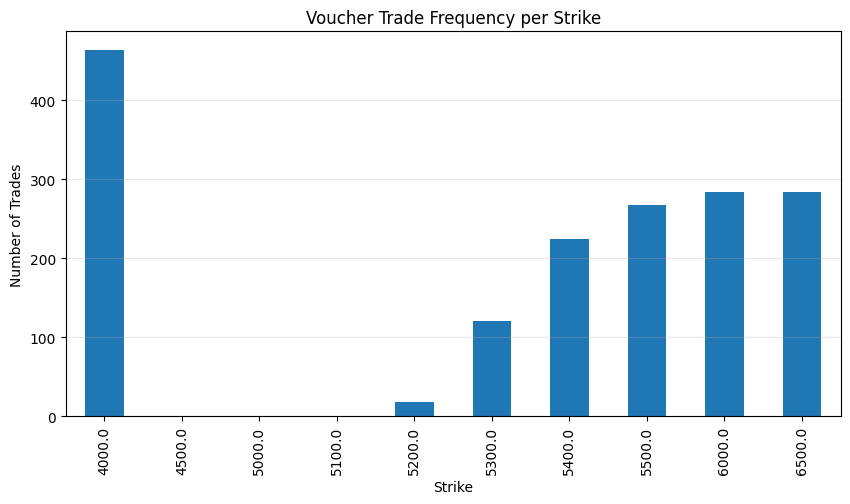

In [ ]:
voucher_trades = trades[trades["product"].str.contains("VEV_")]

freq = voucher_trades.groupby("strike").size().sort_index()

plt.figure(figsize=(10,5))
freq.plot(kind="bar")

plt.title("Voucher Trade Frequency per Strike")
plt.xlabel("Strike")
plt.ylabel("Number of Trades")
plt.grid(axis='y', alpha=0.3)
plt.show()

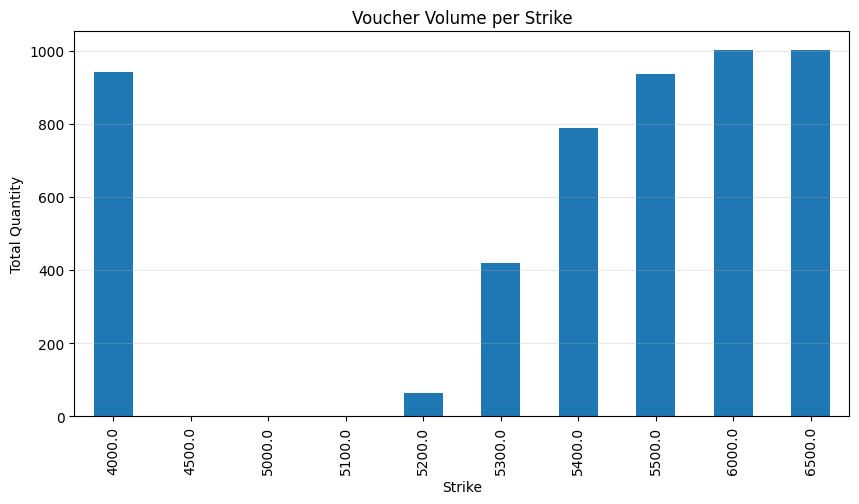

In [ ]:
vol_strike = voucher_trades.groupby("strike")["quantity"].sum().sort_index()

plt.figure(figsize=(10,5))
vol_strike.plot(kind="bar")

plt.title("Voucher Volume per Strike")
plt.xlabel("Strike")
plt.ylabel("Total Quantity")
plt.grid(axis='y', alpha=0.3)
plt.show()